In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("quands/eeg-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eeg-dataset' dataset.
Path to dataset files: /kaggle/input/eeg-dataset


In [21]:
import os
print("Main folder:", os.listdir(path))
print("Dataset folder:", os.listdir(path + "/Dataset"))

Main folder: ['Dataset']
Dataset folder: ['N', 'F', 'S', 'O', 'Z']


In [22]:
#Load the dataset
import numpy as np
import os

data = []
labels = []

base_path = path + "/Dataset"

classes = sorted(os.listdir(base_path))  # ['F', 'N', 'O', 'S', 'Z']

for label, folder in enumerate(classes):
    folder_path = os.path.join(base_path, folder)

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        signal = np.loadtxt(file_path)   # read EEG signal

        data.append(signal)
        labels.append(label)

X = np.array(data)
y = np.array(labels)

print("Data shape:", X.shape)   # (500, timesteps) total samples=500
print("Labels shape:", y.shape)

Data shape: (500, 4097)
Labels shape: (500,)


In [23]:
#Normalize Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)


In [24]:
#Reshape for CNN
X = X.reshape(X.shape[0], X.shape[1], 1)

print("New shape:", X.shape)

New shape: (500, 4097, 1)


In [25]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
import numpy as np

print("Training Samples per Class:")
for i, cls in enumerate(classes):
    count = np.sum(y_train == i)
    print(f"{cls}: {count}")

Training Samples per Class:
F: 72
N: 86
O: 90
S: 76
Z: 76


In [27]:
print("Testing Samples per Class:")
for i, cls in enumerate(classes):
    count = np.sum(y_test == i)
    print(f"{cls}: {count}")

Testing Samples per Class:
F: 28
N: 14
O: 10
S: 24
Z: 24


In [28]:
#Build 1D CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv1D(32, 3, activation='relu', input_shape=(X.shape[1], 1)))
model.add(MaxPooling1D(2))

model.add(Conv1D(64, 3, activation='relu'))
model.add(MaxPooling1D(2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(5, activation='softmax'))  # 5 classes

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 4095, 32)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 2047, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 2045, 64)       │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 1022, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 65408)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     8,372,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,379,333 (31.96 MB)

 Trainable params: 8,379,333 (31.96 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#Compile Model
model.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train, y_train,
    epochs=20,          # allow learning
    batch_size=32,      # smaller = better generalization
    validation_data=(X_test, y_test),
)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 249ms/step - accuracy: 0.2275 - loss: 2.2656 - val_accuracy: 0.4300 - val_loss: 1.3742
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 222ms/step - accuracy: 0.3550 - loss: 1.4113 - val_accuracy: 0.5200 - val_loss: 1.2719
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 315ms/step - accuracy: 0.5300 - loss: 1.2378 - val_accuracy: 0.5700 - val_loss: 1.1265
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 224ms/step - accuracy: 0.5900 - loss: 1.0808 - val_accuracy: 0.6300 - val_loss: 1.0051
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.6250 - loss: 0.9096 - val_accuracy: 0.6100 - val_loss: 0.8622
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.7475 - loss: 0.7280 - val_accuracy: 0.6600 - val_loss: 0.7338
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 236ms/step - accuracy: 0.8100 - loss: 0.5581 - val_accuracy: 0.7800 - val_loss: 0.5797
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.8250 - loss: 0.5130 - val_accuracy: 0.

In [32]:
#Evaluate Model
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8600 - loss: 0.3744
Test Accuracy: 0.8600000143051147


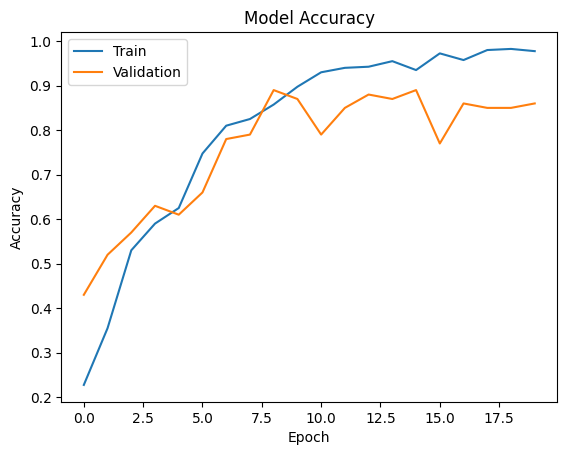

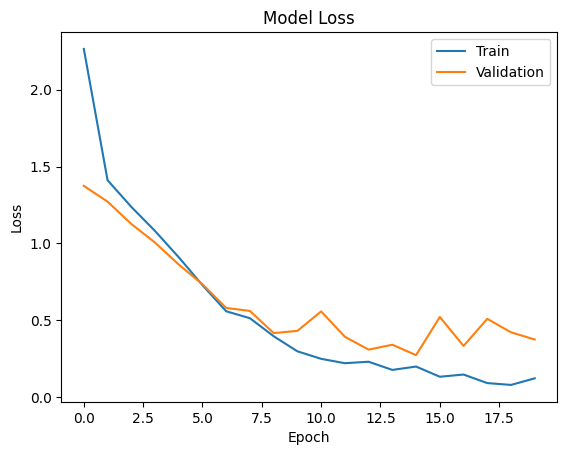

In [33]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [34]:
#Predictions
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

[[23  4  0  1  0]
 [ 0 13  1  0  0]
 [ 0  0  8  1  1]
 [ 0  0  1 23  0]
 [ 1  2  2  0 19]]


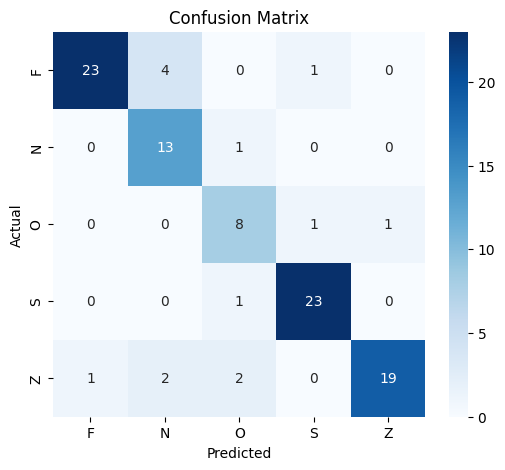

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

classes = ['F', 'N', 'O', 'S', 'Z']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes, target_names=['F','N','O','S','Z']))

              precision    recall  f1-score   support

           F       0.96      0.82      0.88        28
           N       0.68      0.93      0.79        14
           O       0.67      0.80      0.73        10
           S       0.92      0.96      0.94        24
           Z       0.95      0.79      0.86        24

    accuracy                           0.86       100
   macro avg       0.84      0.86      0.84       100
weighted avg       0.88      0.86      0.86       100



In [39]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
fold_no = 1

for train_index, test_index in kf.split(X, y):

    print(f"\n🔹 Fold {fold_no}")

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Build model
    model = Sequential()

    model.add(Conv1D(32, 3, activation='relu', input_shape=(X.shape[1],1)))
    model.add(MaxPooling1D(2))

    model.add(Conv1D(64, 3, activation='relu'))
    model.add(MaxPooling1D(2))

    model.add(Flatten())

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(5, activation='softmax'))

    # Compile
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    # Evaluate
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Accuracy: {acc:.4f}")

    fold_accuracies.append(acc)
    fold_no += 1

# Final Result
print("\nK-Fold Accuracies:", fold_accuracies)
print("Average Accuracy:", np.mean(fold_accuracies))


🔹 Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8000

🔹 Fold 2
Accuracy: 0.8000

🔹 Fold 3
Accuracy: 0.8400

🔹 Fold 4
Accuracy: 0.7900

🔹 Fold 5
Accuracy: 0.8300

K-Fold Accuracies: [0.800000011920929, 0.800000011920929, 0.8399999737739563, 0.7900000214576721, 0.8299999833106995]
Average Accuracy: 0.8120000004768372



🔹 Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


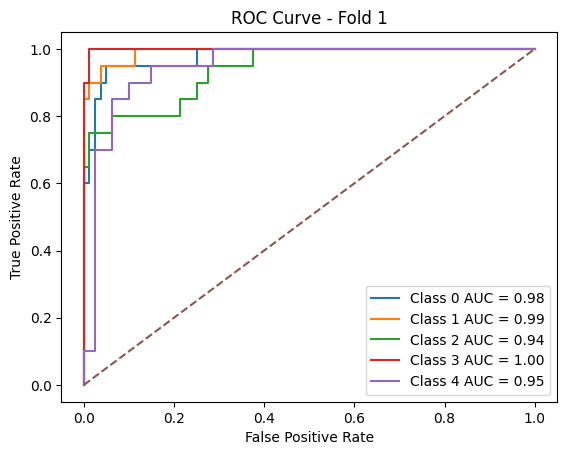


🔹 Fold 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


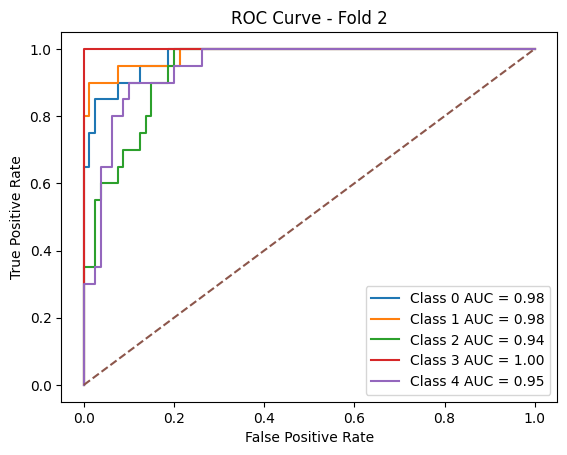


🔹 Fold 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


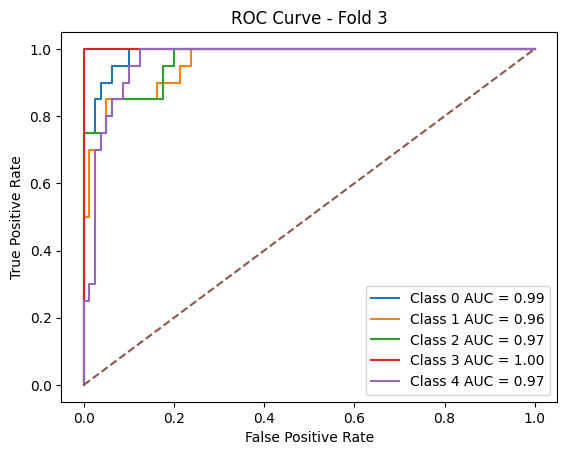


🔹 Fold 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


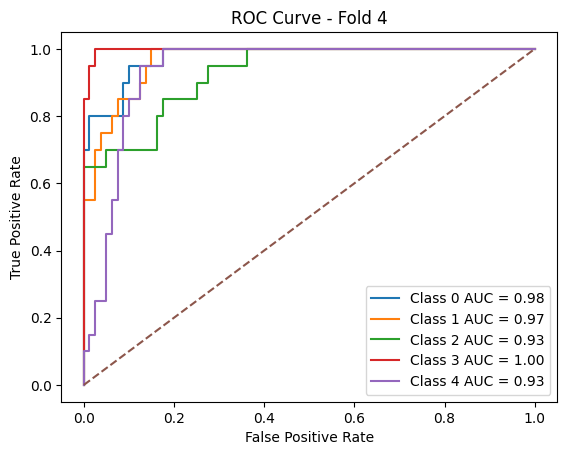


🔹 Fold 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


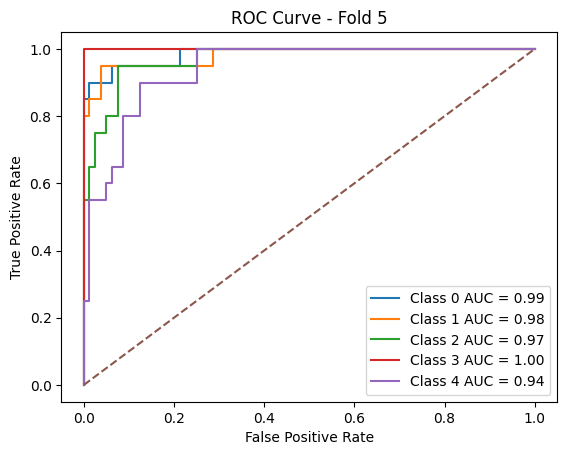

In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Binarize labels for ROC
y_bin = label_binarize(y, classes=[0,1,2,3,4])
n_classes = y_bin.shape[1]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1

for train_index, test_index in kf.split(X, y):

    print(f"\n🔹 Fold {fold_no}")

    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    y_test_bin = y_bin[test_index]

    # Build model
    model = Sequential()

    model.add(Conv1D(32, 3, activation='relu', input_shape=(X.shape[1],1)))
    model.add(MaxPooling1D(2))

    model.add(Conv1D(64, 3, activation='relu'))
    model.add(MaxPooling1D(2))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(5, activation='softmax'))

    # Compile
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    # Predict probabilities
    y_score = model.predict(X_test)

    # ROC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} AUC = {roc_auc[i]:.2f}')

    plt.plot([0,1], [0,1], linestyle='--')  # diagonal
    plt.title(f'ROC Curve - Fold {fold_no}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()

    fold_no += 1